In [1]:
# import warnings is simply used to remove warnings about incompatibility with future Pandas update on Nate's device
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
from HT_func_run_all_functions import *
import pandas as pd
from ipynb.fs.defs.HT_working_file import (construct_calendar_year_list, 
                                            construct_business_case_year_list, 
                                            construct_operations_years_list, 
                                            construct_decomissioning_years_list, 
                                            construction_phase,
                                            operational_phase,
                                            decommissioning_phase,
                                            taxes_and_profits_part1,
                                            debt_and_loan_part1,
                                            taxes_and_profits_part2,
                                            debt_and_loan_part2,
                                            project_reserves,
                                            equity_funding,
                                            present_value_cashflows,
                                            cumulative_equity_and_debt_cashflows,
                                            discounted_cashflows_for_levelized_cost,
                                            levelized_cost_and_revenues,
                                            project_kpi,
                                            equity_kpi,
                                            output_kpi)
from HT_input_data import *
import importlib
import HT_input_data
from NSE_get_data_from_ESDL import *

XMLResource loading...
All variables saved to NSE_get_data_from_ESDL.pkl


In [3]:
file_names = ["TNVDW_cost_single_units_v1_pessimistic_scenario.esdl", "TNVDW_cost_single_units_v1_most_likely_scenario.esdl", "TNVDW_cost_single_units_v1_optimistic_scenario.esdl"]

# make a dataframe that will contain the levelized costs and revenues from all scenarios    
# Define the levels of the MultiIndex
groups = ['Pessimistic', 'Most likely', 'Optimistic']  # Group names
sub_columns = ['Costs', 'Revenues']  # Sub-column names

# Create the MultiIndex from the groups and sub_columns
multi_index = pd.MultiIndex.from_product([groups, sub_columns], names=['Scenario', 'Type'])

# Create an empty DataFrame with the multi-level columns
df_lcr_all_scenarios = pd.DataFrame(columns=multi_index)

# Make a dataframe that will contain all kpi results
df_kpi_results = pd.DataFrame(columns=['Pessimistic', 'Most likely', 'Optimistic', 'Unit'])


for x in file_names:

    esh = EnergySystemHandler()
    esh.load_file(x)
    energy_system = esh.get_energy_system()
    instance_list = energy_system.instance
    my_instance = instance_list[0]

    if x == file_names[0]:
        drop_scenarios = ['most_likely','optimistic']
    elif x == file_names[1]:
        drop_scenarios = ['pessimistic','optimistic']
    else: 
        drop_scenarios = ['pessimistic','most_likely']

    save_to_pickle(drop_scenarios, asset_parameters)

    importlib.reload(HT_input_data)
    

    



    HT_run_all_functions(HT_input_data.pipeline_capex, 
                         HT_input_data.compression_capex,                  
                         HT_input_data.df_HT_opex,
                         HT_input_data.df_opex_compressor,
                         HT_input_data.df_HT_compressor_power_costs,
                         HT_input_data.HT_inflation,
                         HT_input_data.df_HT_revenues_transport, 
                         HT_input_data.df_HT_revenues_connections,
                         HT_input_data.HT_decomissioning_percentage,
                         HT_input_data.HT_loan_percentage,
                         HT_input_data.HT_loan_interest_rate,
                         HT_input_data.HT_income_tax_rate,
                         HT_input_data.HT_general_WACC,
                         HT_input_data.HT_lifetime,
                         HT_input_data.pipeline_distance)
    
    
    levelized_cost = levelized_cost_and_revenues(HT_input_data.pipeline_capex, 
                                                HT_input_data.compression_capex,                  
                                                HT_input_data.df_HT_opex,
                                                HT_input_data.df_opex_compressor,
                                                HT_input_data.df_HT_compressor_power_costs,
                                                HT_input_data.HT_inflation,
                                                HT_input_data.df_HT_revenues_transport, 
                                                HT_input_data.df_HT_revenues_connections,
                                                HT_input_data.HT_decomissioning_percentage,
                                                HT_input_data.HT_loan_percentage,
                                                HT_input_data.HT_loan_interest_rate,
                                                HT_input_data.HT_income_tax_rate,
                                                HT_input_data.HT_general_WACC,
                                                HT_input_data.HT_lifetime,
                                                HT_input_data.pipeline_distance)
    
    project_result = project_kpi(HT_input_data.pipeline_capex, 
                                HT_input_data.compression_capex,                  
                                HT_input_data.df_HT_opex,
                                HT_input_data.df_opex_compressor,
                                HT_input_data.df_HT_compressor_power_costs,
                                HT_input_data.HT_inflation,
                                HT_input_data.df_HT_revenues_transport, 
                                HT_input_data.df_HT_revenues_connections,
                                HT_input_data.HT_decomissioning_percentage,
                                HT_input_data.HT_loan_percentage,
                                HT_input_data.HT_loan_interest_rate,
                                HT_input_data.HT_income_tax_rate,
                                HT_input_data.HT_general_WACC,
                                HT_input_data.HT_lifetime,
                                HT_input_data.pipeline_distance)

    equity_result = equity_kpi(HT_input_data.pipeline_capex, 
                                HT_input_data.compression_capex,                  
                                HT_input_data.df_HT_opex,
                                HT_input_data.df_opex_compressor,
                                HT_input_data.df_HT_compressor_power_costs,
                                HT_input_data.HT_inflation,
                                HT_input_data.df_HT_revenues_transport, 
                                HT_input_data.df_HT_revenues_connections,
                                HT_input_data.HT_decomissioning_percentage,
                                HT_input_data.HT_loan_percentage,
                                HT_input_data.HT_loan_interest_rate,
                                HT_input_data.HT_income_tax_rate,
                                HT_input_data.HT_general_WACC,
                                HT_input_data.HT_lifetime,
                                HT_input_data.pipeline_distance)

    output_result = output_kpi(HT_input_data.pipeline_capex, 
                                HT_input_data.compression_capex,                  
                                HT_input_data.df_HT_opex,
                                HT_input_data.df_opex_compressor,
                                HT_input_data.df_HT_compressor_power_costs,
                                HT_input_data.HT_inflation,
                                HT_input_data.df_HT_revenues_transport, 
                                HT_input_data.df_HT_revenues_connections,
                                HT_input_data.HT_decomissioning_percentage,
                                HT_input_data.HT_loan_percentage,
                                HT_input_data.HT_loan_interest_rate,
                                HT_input_data.HT_income_tax_rate,
                                HT_input_data.HT_general_WACC,
                                HT_input_data.HT_lifetime,
                                HT_input_data.pipeline_distance)


    # create a temporary column of dummy data at the top-level of the MultiIndex (which will later be dropped)
    # without first creating this temporary column, pandas will not be able to assign values to the MultiIndex df
    df_lcr_all_scenarios.loc[:, 'temp'] = levelized_cost['cost']
    if x == file_names[0]:
        # add to pessimistic
        df_lcr_all_scenarios.loc[:, ('Pessimistic','Costs')] = levelized_cost['cost']
        df_lcr_all_scenarios.loc[:, ('Pessimistic','Revenues')] = levelized_cost['revenues'] 

        project_result_pes = project_result.drop(columns=['Unit'])
        project_result_pes.rename(columns={'Value':'Pessimistic'}, inplace=True)
        equity_result_pes = equity_result.drop(columns=['Unit'])
        equity_result_pes.rename(columns={'Value':'Pessimistic'}, inplace=True)
        output_result_pes = output_result.drop(columns=['Unit'])
        output_result_pes.rename(columns={'Value':'Pessimistic'}, inplace=True)

    elif x == file_names[1]:
        # add to most_likely
        df_lcr_all_scenarios.loc[:, ('Most likely','Costs')] = levelized_cost['cost']
        df_lcr_all_scenarios.loc[:, ('Most likely','Revenues')] = levelized_cost['revenues']

        project_result_ml = project_result.drop(columns=['Unit'])
        project_result_ml.rename(columns={'Value':'Most likely'}, inplace=True)
        equity_result_ml = equity_result.drop(columns=['Unit'])
        equity_result_ml.rename(columns={'Value':'Most likely'}, inplace=True)
        output_result_ml = output_result.drop(columns=['Unit'])
        output_result_ml.rename(columns={'Value':'Most likely'}, inplace=True)

    else: 
        # add to optimistic
        df_lcr_all_scenarios.loc[:, ('Optimistic','Costs')] = levelized_cost['cost']
        df_lcr_all_scenarios.loc[:, ('Optimistic','Revenues')] = levelized_cost['revenues']

        project_result_opt = project_result
        project_result_opt.rename(columns={'Value':'Optimistic'}, inplace=True)
        equity_result_opt = equity_result
        equity_result_opt.rename(columns={'Value':'Optimistic'}, inplace=True)
        output_result_opt = output_result
        output_result_opt.rename(columns={'Value':'Optimistic'}, inplace=True)

df_project_kpi_results = pd.concat([project_result_pes, project_result_ml, project_result_opt], axis=1)
df_equity_kpi_results = pd.concat([equity_result_pes, equity_result_ml, equity_result_opt], axis=1)
df_output_kpi_results = pd.concat([output_result_pes, output_result_ml, output_result_opt], axis=1)

project_kpi_row = pd.DataFrame({"Pessimistic":[""],"Most likely":[""],"Optimistic":[""], "Unit":[""]}, index=["Project KPI's"])
equity_kpi_row = pd.DataFrame({"Pessimistic":[""],"Most likely":[""],"Optimistic":[""], "Unit":[""]}, index=["Equity KPI's"])
output_kpi_row = pd.DataFrame({"Pessimistic":[""],"Most likely":[""],"Optimistic":[""], "Unit":[""]}, index=["Output KPI's"])

df_project_kpi_results = pd.concat([project_kpi_row, df_project_kpi_results], axis=0)
df_equity_kpi_results = pd.concat([equity_kpi_row, df_equity_kpi_results], axis=0)
df_output_kpi_results = pd.concat([output_kpi_row, df_output_kpi_results], axis=0)

df_kpi_results = pd.concat([df_project_kpi_results, df_equity_kpi_results, df_output_kpi_results], axis=0)

        
# drop temporary column that was only used for correct multi-level dataframe assignment        
df_lcr_all_scenarios = df_lcr_all_scenarios.drop(columns='temp')

df_lcr_all_scenarios

XMLResource loading...
All variables saved to NSE_get_data_from_ESDL.pkl
XMLResource loading...
All variables saved to NSE_get_data_from_ESDL.pkl
XMLResource loading...
All variables saved to NSE_get_data_from_ESDL.pkl


C:\Users\DinaBoer\AppData\Local\Temp\ipykernel_10412\4186679218.py:179: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df_lcr_all_scenarios = df_lcr_all_scenarios.drop(columns='temp')


Scenario                     Pessimistic           Most likely            \
Type                               Costs  Revenues       Costs  Revenues   
pipeline_capex                  2.071624       0.0    0.953434       0.0   
compression_capex               1.756254       0.0    1.710598       0.0   
opex                            0.997136       0.0    1.008845       0.0   
opex_compressor                 1.063165       0.0     1.07565       0.0   
compressor_power_consumption    2.471933       0.0    2.115758       0.0   
decommissioning_pipeline        0.030613       0.0    0.017364       0.0   
decommissioning_compressor      0.012302       0.0    0.013956       0.0   
interest_costs                  1.103075       0.0    0.420684       0.0   
contingency                      0.14449       0.0    0.081289       0.0   
tax_expenses                        -0.0       0.0        -0.0       0.0   
revenues_connection_tariffs         -0.0       0.0        -0.0       0.0   
revenues_transport_tariffs          -0.0       0.0        -0.0       0.0   
profits                              0.0       0.0         0.0       0.0   
unprofitable_gap                     0.0  9.650592         0.0  7.397578   

Scenario                     Optimistic            
Type                              Costs  Revenues  
pipeline_capex                 0.874895       0.0  
compression_capex              1.666533       0.0  
opex                            1.02101       0.0  
opex_compressor                 1.08862       0.0  
compressor_power_consumption   1.244838       0.0  
decommissioning_pipeline       0.019657       0.0  
decommissioning_compressor     0.015799       0.0  
interest_costs                 0.230184       0.0  
contingency                    0.070032       0.0  
tax_expenses                       -0.0       0.0  
revenues_connection_tariffs        -0.0       0.0  
revenues_transport_tariffs         -0.0       0.0  
profits                             0.0       0.0  
unprofitable_gap                    0.0  6.231568

All KPI results

In [4]:
def clean_index_name(index):
    index = index.replace("_", " ")  # Replace underscores with spaces
    index = index.capitalize()  # Capitalize the first letter
    index = index.replace("kpi's", "KPI's")
    index = index.replace("EUR", "€")
    return index

# Apply the function to each index name
new_index_names = {index: clean_index_name(index) for index in df_kpi_results.index}

# Rename the index using the dictionary
df_kpi_results.rename(index=new_index_names, inplace=True)

# Change EUR to €
df_kpi_results['Unit'] = df_kpi_results['Unit'].replace({'Eur/MWh': '€/MWh', 'MEUR': '€'})

# Display the cleaned-up DataFrame
df_kpi_results.style.format(precision=2)


,Pessimistic,Most likely,Optimistic,Unit
Project KPI's,,,,
Net present value,-10310.72,-9338.64,-8878.19,€
Internal rate of return,nan,nan,nan,%
Return on investment,-363.40,-370.18,-308.24,%
Payback period,-11.01,-10.81,-12.98,years
Discounted return on investment,-290.17,-403.54,-379.02,%
Discounted payback period,-21.03,-13.18,-14.34,years
Equity KPI's,,,,
Net present value,-9255.64,-8165.41,-7523.38,€
Internal rate of return,nan,nan,nan,%


In [5]:
# This can be used to copy the dataframe into Excel

df_kpi_results.to_clipboard()

Clean up column names to improve visualisation in the graph

In [6]:
# transpose dataframe to prepare for plotting
t_df_lcr_all_scenarios = df_lcr_all_scenarios.T

def clean_column_name(col):
    col = col.replace("_", " ")  # Replace underscores with spaces
    col = col.capitalize()  # Capitalize the first letter
    col = col.replace("Capex", "CAPEX")
    col = col.replace("capex", "CAPEX")
    col = col.replace("Opex", "OPEX")
    col = col.replace("ppa", "PPA")
    return col

# Apply the function to each column name
new_column_names = {col: clean_column_name(col) for col in t_df_lcr_all_scenarios.columns}

# Rename the columns using the dictionary
t_df_lcr_all_scenarios.rename(columns=new_column_names, inplace=True)

t_df_lcr_all_scenarios

Pipeline CAPEX Compression CAPEX      OPEX  \
Scenario    Type                                                  
Pessimistic Costs          2.071624          1.756254  0.997136   
            Revenues            0.0               0.0       0.0   
Most likely Costs          0.953434          1.710598  1.008845   
            Revenues            0.0               0.0       0.0   
Optimistic  Costs          0.874895          1.666533   1.02101   
            Revenues            0.0               0.0       0.0   

                     OPEX compressor Compressor power consumption  \
Scenario    Type                                                    
Pessimistic Costs           1.063165                     2.471933   
            Revenues             0.0                          0.0   
Most likely Costs            1.07565                     2.115758   
            Revenues             0.0                          0.0   
Optimistic  Costs            1.08862                     1.244838   
            Revenues             0.0                          0.0   

                     Decommissioning pipeline Decommissioning compressor  \
Scenario    Type                                                           
Pessimistic Costs                    0.030613                   0.012302   
            Revenues                      0.0                        0.0   
Most likely Costs                    0.017364                   0.013956   
            Revenues                      0.0                        0.0   
Optimistic  Costs                    0.019657                   0.015799   
            Revenues                      0.0                        0.0   

                     Interest costs Contingency Tax expenses  \
Scenario    Type                                               
Pessimistic Costs          1.103075     0.14449         -0.0   
            Revenues            0.0         0.0          0.0   
Most likely Costs          0.420684    0.081289         -0.0   
            Revenues            0.0         0.0          0.0   
Optimistic  Costs          0.230184    0.070032         -0.0   
            Revenues            0.0         0.0          0.0   

                     Revenues connection tariffs Revenues transport tariffs  \
Scenario    Type                                                              
Pessimistic Costs                           -0.0                       -0.0   
            Revenues                         0.0                        0.0   
Most likely Costs                           -0.0                       -0.0   
            Revenues                         0.0                        0.0   
Optimistic  Costs                           -0.0                       -0.0   
            Revenues                         0.0                        0.0   

                     Profits Unprofitable gap  
Scenario    Type                               
Pessimistic Costs        0.0              0.0  
            Revenues     0.0         9.650592  
Most likely Costs        0.0              0.0  
            Revenues     0.0         7.397578  
Optimistic  Costs        0.0              0.0  
            Revenues     0.0         6.231568

Make graph

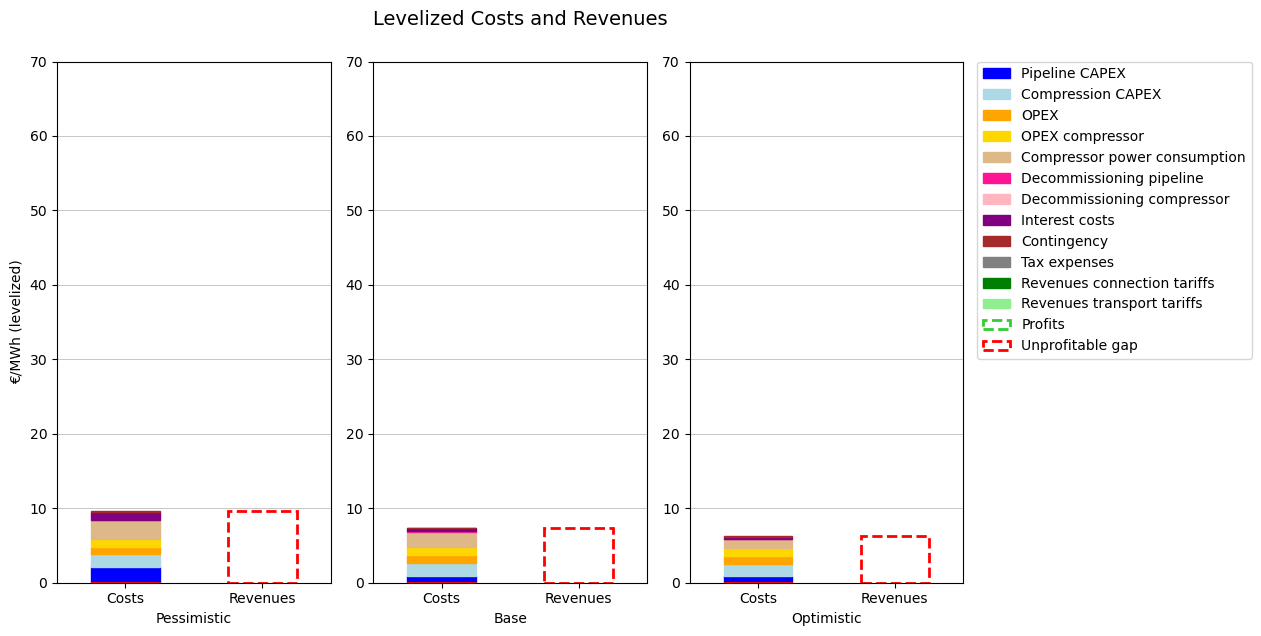

In [7]:
import matplotlib.pyplot as plt

# Define specific colors for each variable
color_mapping = {
    'Pipeline CAPEX': 'blue',
    'Compression CAPEX': 'lightblue',
    'OPEX': 'orange',
    'OPEX compressor': 'gold',
    'Compressor power consumption': 'burlywood',
    'Decommissioning pipeline': '#FF1493',
    'Decommissioning compressor': 'lightpink',
    'Interest costs': 'purple',
    'Contingency': 'brown',
    'Tax expenses': 'grey',
    'Revenues connection tariffs': 'green',
    'Revenues transport tariffs': 'lightgreen',
    'Profits': 'limegreen',
    'Unprofitable gap': 'red'  
}

# Plot levelized costs and revenues
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 6))
# plt.suptitle('Levelized Costs and Revenues')

# List of axes
axes = [ax1, ax2, ax3]

# Get column names
column_names = t_df_lcr_all_scenarios.columns

# Plot each scenario and apply custom colors
for ax, scenario in zip(axes, ['Pessimistic', 'Most likely', 'Optimistic']):
    xlabel = 'Base' if scenario == 'Most likely' else scenario
    plot = t_df_lcr_all_scenarios.loc[scenario].plot(
        kind='bar', stacked=True, ax=ax, rot='horizontal', legend=False,
        xlabel=xlabel, ylabel='€/MWh (levelized)' if ax == ax1 else None
    )
    
    # Iterate through bars and assign colors based on the variable name
    for i, bar in enumerate(ax.containers):
        for patch in bar:
            col_name = column_names[i]  # Get the corresponding column name
            
            if col_name == 'Unprofitable gap':  # Apply dashed line for 'Unprofitable gap'
                patch.set_edgecolor('red')  # Set edge color for the outline
                patch.set_linestyle('--')    # Set the edge line to dashed
                patch.set_linewidth(2)      # Make the dashed line thicker for visibility
                patch.set_facecolor('white')  # Set the fill color to white to only show outline
            elif col_name == "Profits":
                patch.set_edgecolor('limegreen')  # Set edge color for the outline
                patch.set_linestyle('--')    # Set the edge line to dashed
                patch.set_linewidth(2)      # Make the dashed line thicker for visibility
                patch.set_facecolor('white')  # Set the fill color to white to only show outline
            else:
                # Use the color mapping for other variables
                patch.set_color(color_mapping.get(col_name, 'gray'))  # Default to gray if not found

# Add a custom title above the "Most likely" plot
fig.text(0.35, 1.02, 'Levelized Costs and Revenues', ha='center', va='bottom', fontsize=14)


# Add a single legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Apply grid and y-limit to all axes
for ax in axes:
    ax.grid(True, which='major', axis='y', linestyle='-', linewidth=0.5)
    ax.set_ylim(0, 70)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust layout to make space for the legend
plt.show()


In [8]:
HT_hydrogen_volume

,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2090,2091,2092,2093,2094,2095,2096,2097,2098,2099
HT_hydrogen_volume,83247503.262119,83247503.262119,83247503.262119,83247503.262119,83247503.262119,83247503.262119,83247503.262119,83247503.262119,83247503.262119,83247503.262119,...,83247503.262119,83247503.262119,83247503.262119,83247503.262119,83247503.262119,83247503.262119,83247503.262119,83247503.262119,83247503.262119,83247503.262119


Make graph without costs

In [9]:
df = t_df_lcr_all_scenarios.loc[t_df_lcr_all_scenarios.index.get_level_values('Type') != 'Revenues']
df = df.drop(['Unprofitable gap', 'Revenues transport tariffs', 'Revenues connection tariffs'], axis=1)
df = df.drop(["Profits"], axis=1)



In [10]:
df

,,Pipeline CAPEX,Compression CAPEX,OPEX,OPEX compressor,Compressor power consumption,Decommissioning pipeline,Decommissioning compressor,Interest costs,Contingency,Tax expenses
Scenario,Type,,,,,,,,,,
Pessimistic,Costs,2.071624,1.756254,0.997136,1.063165,2.471933,0.030613,0.012302,1.103075,0.14449,-0.0
Most likely,Costs,0.953434,1.710598,1.008845,1.07565,2.115758,0.017364,0.013956,0.420684,0.081289,-0.0
Optimistic,Costs,0.874895,1.666533,1.02101,1.08862,1.244838,0.019657,0.015799,0.230184,0.070032,-0.0


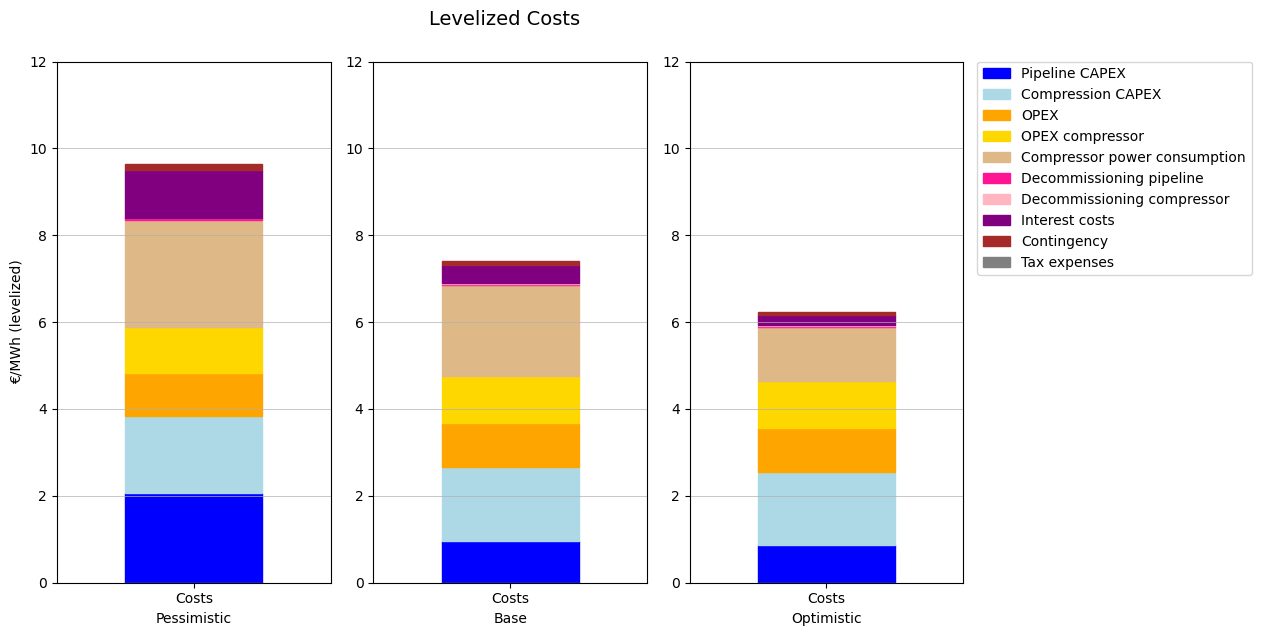

In [11]:
import matplotlib.pyplot as plt

# Define specific colors for each variable
color_mapping = {
    'Pipeline CAPEX': 'blue',
    'Compression CAPEX': 'lightblue',
    'OPEX': 'orange',
    'OPEX compressor': 'gold',
    'Compressor power consumption': 'burlywood',
    'Decommissioning pipeline': '#FF1493',
    'Decommissioning compressor': 'lightpink',
    'Interest costs': 'purple',
    'Contingency': 'brown',
    'Tax expenses': 'grey',
    'Revenues connection tariffs': 'green',
    'Revenues transport tariffs': 'lightgreen',
    'Profits': 'limegreen',
    'Unprofitable gap': 'red'  
}

# Plot levelized costs and revenues
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 6))
# plt.suptitle('Levelized Costs and Revenues')

# List of axes
axes = [ax1, ax2, ax3]

# Get column names
column_names = df

# Plot each scenario and apply custom colors
for ax, scenario in zip(axes, ['Pessimistic', 'Most likely', 'Optimistic']):
    xlabel = 'Base' if scenario == 'Most likely' else scenario
    plot = df.loc[scenario].plot(
        kind='bar', stacked=True, ax=ax, rot='horizontal', legend=False,
        xlabel=xlabel, ylabel='€/MWh (levelized)' if ax == ax1 else None
    )
    

    # Iterate through bars and assign colors based on the variable name
    for i, (patches, col_name) in enumerate(zip(ax.containers, column_names)):  
        for patch in patches:  
            if col_name == 'Unprofitable gap':  
                patch.set_edgecolor('red')  
                patch.set_linestyle('--')    
                patch.set_linewidth(2)      
                patch.set_facecolor('white')  
            elif col_name == "Profits":  
                patch.set_edgecolor('limegreen')  
                patch.set_linestyle('--')    
                patch.set_linewidth(2)      
                patch.set_facecolor('white')  
            else:  
                patch.set_color(color_mapping.get(col_name, 'gray'))  



# Add a custom title above the "Most likely" plot
fig.text(0.34, 1.02, 'Levelized Costs', ha='center', va='bottom', fontsize=14)


# Add a single legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Apply grid and y-limit to all axes
for ax in axes:
    ax.grid(True, which='major', axis='y', linestyle='-', linewidth=0.5)
    ax.set_ylim(0, 12)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust layout to make space for the legend
plt.show()
